# Waterfall

## Pré-requis (pour exécuter les tests)

- Le simulateur utilisé est `waterfall_simpy.py`.
- Il dépend de `simpy` (à installer dans le même environnement Python que votre kernel Jupyter).

Installation (si nécessaire) :
```bash
pip install simpy
```

In [23]:
from __future__ import annotations

from pathlib import Path
import csv
import sys
import statistics
import subprocess
from typing import Any


# Ajustez ces paramètres si les runs sont trop longs.
DEFAULT_SIM_TIME = 5_000
DEFAULT_RUNS = 20
DEFAULT_SEED = 42


if not Path("waterfall_simpy.py").exists():
    raise FileNotFoundError("waterfall_simpy.py introuvable dans le dossier courant.")

try:
    import simpy  # noqa: F401
except ModuleNotFoundError:
    print("Installation de 'simpy' via pip…")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "simpy"])
    import simpy  # noqa: F401


def run_waterfall(
    *,
    out_prefix: str,
    out_dir: str,
    lam: float,
    mu_exec: float,
    mu_send: float,
    K: int,
    ks: int = 0,
    kf: int = 0,
    sim_time: float = DEFAULT_SIM_TIME,
    grace: float = 200,
    runs: int = DEFAULT_RUNS,
    seed: int = DEFAULT_SEED,
    backup: str = "none",
    backup_p: float = 0.5,
) -> tuple[Path, Path]:
    """Lance `waterfall_simpy.py` et renvoie les chemins vers les CSV (summary, jobs)."""
    cmd = [
        "python3",
        "waterfall_simpy.py",
        "--lam",
        str(lam),
        "--mu-exec",
        str(mu_exec),
        "--mu-send",
        str(mu_send),
        "--K",
        str(K),
        "--ks",
        str(ks),
        "--kf",
        str(kf),
        "--sim-time",
        str(sim_time),
        "--grace",
        str(grace),
        "--runs",
        str(runs),
        "--seed",
        str(seed),
        "--backup",
        str(backup),
        "--backup-p",
        str(backup_p),
        "--out-dir",
        out_dir,
        "--out-prefix",
        out_prefix,
    ]
    subprocess.run(cmd, check=True)
    return (
        Path(out_dir) / f"{out_prefix}_summary.csv",
        Path(out_dir) / f"{out_prefix}_jobs.csv",
    )


def read_csv_dicts(path: Path) -> list[dict[str, str]]:
    with path.open(newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def mean_metric(rows: list[dict[str, str]], key: str) -> float:
    values = [float(r[key]) for r in rows if r.get(key) not in (None, "")]
    return statistics.mean(values) if values else 0.0


def summarize_experiment(summary_csv: Path) -> dict[str, float]:
    rows = read_csv_dicts(summary_csv)
    if not rows:
        return {}
    keys = [
        "rate_blocked_submit",
        "rate_blocked_forward",
        "rate_dropped",
        "mean_time_in_system",
        "var_time_in_system",
        "utilization_exec",
        "rest_in_backup",
        "rest_in_forward",
        "not_completed_yet",
        "arrivals",
        "completed",
    ]
    return {k: mean_metric(rows, k) for k in keys if k in rows[0]}


def print_table(rows: list[dict[str, Any]], cols: list[str]) -> None:
    def fmt(v: Any) -> str:
        if isinstance(v, float):
            return f"{v:.4g}"
        return str(v)

    widths: dict[str, int] = {}
    for c in cols:
        w = len(c)
        for r in rows:
            w = max(w, len(fmt(r.get(c, ""))))
        widths[c] = w

    header = " | ".join(c.ljust(widths[c]) for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in rows:
        print(" | ".join(fmt(r.get(c, "")).ljust(widths[c]) for c in cols))


## <span style="color:#4a90e2"> 1) Proposez un système d’attente modélisant le contexte décrit ci-dessus. Effectuez quelques simulations pour analyser son comportement selon les paramètres en jeu. 

Le workflow décrit se modélise par un **réseau de files en tandem** à deux étages :

- **Étape 1 (exécution de la test-suite)** : file FIFO servie par $K$ serveurs parallèles. Sous hypothèses standard (arrivées Poisson, services exponentiels), on l’approxime par une file $M/M/K$ de taux d’arrivée $\lambda$ et de taux de service par serveur $\mu_1$.
- **Étape 2 (envoi des résultats)** : file FIFO servie par un serveur unique, modélisable par $M/M/1$ de taux de service $\mu_2$.

On introduit les **charges** (taux d’occupation) :

$$
\rho_1 = \frac{\lambda}{K\mu_1},\qquad
\rho_2 = \frac{\lambda}{\mu_2}.
$$

Dans cette approximation, la stabilité requiert $\rho_1<1$ et $\rho_2<1$, c’est‑à‑dire $\lambda < K\mu_1$ et $\lambda < \mu_2$. Le goulet d’étranglement correspond à l’étage dont la charge est la plus proche de 1 (souvent l’envoi).

**Appui expérimental (tests ci-dessous)** en files infinies, avec $K=3$, $\mu_1=1$ (exécution) et $\mu_2=1.5$ (envoi) :
- Pour $\lambda=0.5$ et $\lambda=1$, le système reste stable : $\mathbb{E}[T]\approx 2.02$ puis $3.051$ et aucun backlog en fin de simulation.
- Dès $\lambda=2$, on a $\rho_2 = 2/1.5 \approx 1.33 > 1$ : le **temps de séjour moyen augmente très fortement** ($\approx 647$) et un backlog apparaît ($\approx 2200$ jobs non terminés).
- À $\lambda=3$ et $\lambda=4$, $\mathbb{E}[T]$ et le backlog augmentent encore (jusqu’à $\approx 1.6\times 10^3$), ce qui est cohérent avec une dynamique instable dominée par l’étape 2.

Ces observations confirment que, pour ces paramètres, l’**étape 2** est limitante : à $\lambda=2$, $\rho_1 = 2/(3\cdot 1)=2/3<1$ alors que $\rho_2>1$.

### Appui expérimental attendu

- Variation de λ, K, μ_exec, μ_send

- Observation du temps de séjour moyen et de sa divergence en régime instable

- Identification de l’étage limitant

In [ ]:
# Tests Q1 — files infinies (ks=0, kf=0) : variation de λ, K, μ
# Interprétation attendue : quand le système approche/surpasse la saturation,
# - le temps moyen en système augmente fortement,
# - le backlog en fin de simulation (`not_completed_yet`) augmente.

OUT_DIR = "results_q1"

mu_exec = 1.0
mu_send = 1.5
K = 3
ks = 0  # infini
kf = 0  # infini

lam_values = [0.5, 1.0, 2.0, 3.0, 4.0]

rows = []
for lam in lam_values:
    prefix = f"q1_lam{lam}_K{K}_mue{mu_exec}_mus{mu_send}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup="none",
    )
    s = summarize_experiment(summary_csv)
    s.update({"lam": lam, "K": K, "mu_exec": mu_exec, "mu_send": mu_send})
    rows.append(s)

print_table(
    rows,
    cols=["lam", "mean_time_in_system", "utilization_exec", "not_completed_yet", "rest_in_forward"],
)


## <span style="color:#4a90e2"> 2) Avec une augmentation significative du nombre d’étudiants, l’hypothèse de files d’attente infinies devient irréaliste. On note ks et kf les tailles respectives des files d’exécution et de renvoi de résultats. Si un push tag est refusé, l’étudiant reçoit un message d’erreur. Si le résultat d’un moulinettage est refusé dans la seconde file, l’étudiant reçoit un retour vide.

### <span style="color:#4a90e2"> Discutez des proportions de refus selon les paramètres.

Avec des capacités finies, on distingue deux mécanismes de refus :

- **Refus à la soumission** : un tag est rejeté si le système d’exécution est plein. Dans notre simulateur, cela correspond à $N_{\mathrm{exec}}(t) \ge k_s$ (jobs en service + en attente), et la métrique associée est `rate_blocked_submit`.
- **Refus au renvoi** (retour vide / « page blanche ») : après exécution, si la file de renvoi contient déjà $k_f$ éléments en attente, le résultat ne peut pas entrer (sans back-up) et est perdu ; la métrique associée est `rate_dropped`.

Les proportions de refus dépendent de $\lambda$, de $k_s$ et $k_f$, mais aussi des capacités de service de chaque étage. L’expérience ci-dessous fixe $K=3$, $\mu_1=1$ (exécution), $\mu_2=1.5$ (envoi), $k_s=15$, $k_f=5$, sans back-up :

- Quand $\lambda$ augmente de 1 à 5, `rate_blocked_submit` croît fortement (de 0 à $\approx 0.399$), ce qui traduit la saturation progressive du premier étage sous contrainte de capacité.
- Le taux de « pages blanches » (`rate_dropped`) augmente d’abord ($\approx 0.031$ à $\lambda=1$, puis $\approx 0.437$ à $\lambda=3$) puis redescend ($\approx 0.302$ à $\lambda=5$). Cette **non‑monotonie** s’explique : quand $\lambda$ devient très élevé, davantage de tags sont bloqués en amont ($k_s$ plein), ce qui réduit le flux atteignant la file de renvoi et donc la probabilité de drop.
- Le temps de séjour moyen `mean_time_in_system` augmente globalement ($\approx 2.684$ à $\lambda=1$ jusqu’à $\approx 8.213$ à $\lambda=5$), indiquant une dégradation de l’expérience utilisateur pour les requêtes acceptées.

Enfin, en gardant $\lambda=4$ et $k_s,k_f$ constants, l’augmentation de $\mu_2$ fait chuter `rate_dropped` (de $\approx 0.548$ à $\mu_2=0.8$ vers $\approx 0.264$ à $\mu_2=2$) et diminue `mean_time_in_system` (de $\approx 11.47$ à $\approx 6.648$), alors que `rate_blocked_submit` reste $\approx 0.252$. Cela confirme que, dans ce réglage, l’envoi est le levier principal pour réduire les retours vides.

### Appui expérimental attendu

- Taux de refus submit (ks) vs λ

- Taux de “pages blanches” (kf) vs λ

- Influence de μ_send comparée à celle de ks/kf

In [25]:
# Tests Q2 — files finies : proportions de refus selon (λ, ks, kf, μ_send)
# Mesures principales :
# - rate_blocked_submit : refus à la soumission (ks plein)
# - rate_dropped        : "page blanche" (kf plein et pas de back-up)

OUT_DIR = "results_q2"

mu_exec = 1.0
K = 3
backup = "none"

# (1) Variation de λ pour des capacités données
ks = 15
kf = 5
mu_send = 1.5
lam_values = [1.0, 2.0, 3.0, 4.0, 5.0]

rows_lam = []
for lam in lam_values:
    prefix = f"q2_lam{lam}_ks{ks}_kf{kf}_mus{mu_send}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup=backup,
    )
    s = summarize_experiment(summary_csv)
    s.update({"lam": lam, "ks": ks, "kf": kf, "mu_send": mu_send})
    rows_lam.append(s)

print("(Q2) Variation de λ (ks, kf fixés)")
print_table(rows_lam, cols=["lam", "rate_blocked_submit", "rate_dropped", "mean_time_in_system"])  

# (2) Influence de μ_send (goulot côté envoi)
lam = 4.0
mu_send_values = [0.8, 1.0, 1.5, 2.0]

rows_mus = []
for mu_send in mu_send_values:
    prefix = f"q2_mus{mu_send}_lam{lam}_ks{ks}_kf{kf}"
    summary_csv, _ = run_waterfall(
        out_prefix=prefix,
        out_dir=OUT_DIR,
        lam=lam,
        mu_exec=mu_exec,
        mu_send=mu_send,
        K=K,
        ks=ks,
        kf=kf,
        backup=backup,
    )
    s = summarize_experiment(summary_csv)
    s.update({"mu_send": mu_send, "lam": lam, "ks": ks, "kf": kf})
    rows_mus.append(s)

print("\n(Q2) Influence de μ_send (λ fixé)")
print_table(rows_mus, cols=["mu_send", "rate_blocked_submit", "rate_dropped", "mean_time_in_system"])  


## <span style="color:#4a90e2"> 3) Pour éviter la perte de données, un back-up des résultats de moulinettage est mis en place en amont de l’envoi vers la seconde file.


### <span style="color:#4a90e2"> 3.a Quel changement cela opère-t-il sur la proportion de pages blanches ?

**Qu’est-ce qu’une page blanche ?**  
Une page blanche correspond à un résultat qui ne peut pas entrer dans la seconde file (renvoi) parce qu’elle est pleine. Dans notre simulation, cela correspond à la métrique `rate_blocked_forward`: c’est une proportion (souvent exprimée en %) parmi les jobs acceptés.

**Comment on teste ici ?**  
On compare deux politiques avec les mêmes paramètres (`K=4`, `kf=20`, `ks` infini, `runs=30`) en faisant varier le taux d’arrivée $\lambda$ (nombre moyen de jobs qui arrivent par unité de temps de simulation).

In [26]:
"""Q3.a — Campagne de simulations : compare les politiques de back-up 'none' et 'systematic' pour plusieurs valeurs de λ.
Écrit un CSV combiné dans `results/q3aA_summary.csv`.
"""

import os
import pandas as pd

from waterfall_simpy import run_one

OUT_DIR = "results"
OUT_PREFIX = "q3aA"

lams = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5]
backup_key_by_label = {
    "sans back-up": "none",
    "aléatoire": "probabilistic",
    "aleatoire": "probabilistic",
    "systématique": "systematic",
    "systematique": "systematic",
}
label_by_key = {
    "none": "sans back-up",
    "probabilistic": "aléatoire",
    "systematic": "systématique",
}

backup_policies = ["none", "systematic"]

mu_exec = 1.0
mu_send = 1.0
K = 4
ks = 0
kf = 20

sim_time = 10000
grace = 2000
runs = 30
seed0 = 42

os.makedirs(OUT_DIR, exist_ok=True)

rows = []
for lam_idx, lam in enumerate(lams):
    for pol_idx, backup in enumerate(backup_policies):
        params = {
            "lam": lam,
            "mu_exec": mu_exec,
            "mu_send": mu_send,
            "K": K,
            "ks": None if ks == 0 else ks,
            "kf": None if kf == 0 else kf,
            "backup": backup,
            "backup_p": 1.0,
            "sim_time": sim_time,
            "grace_time": grace,
            "backup_retry_dt": 0.1,
        }
        for run in range(1, runs + 1):
            seed = seed0 + 10_000 * lam_idx + 100 * pol_idx + run
            s, _jobs = run_one(params, seed=seed)
            s.update({
                "run": run,
                "seed": seed,
                "lam": lam,
                "backup": backup,
                "mu_exec": mu_exec,
                "mu_send": mu_send,
                "K": K,
                "ks": ks,
                "kf": kf,
                "sim_time": sim_time,
                "grace": grace,
            })
            rows.append(s)

summary_csv = os.path.join(OUT_DIR, f"{OUT_PREFIX}_summary.csv")
pd.DataFrame(rows).to_csv(summary_csv, index=False)

print("Wrote:", summary_csv)


Wrote: results/q3aA_summary.csv


Wrote: results/q3aA_rate_blocked_forward.png


backup,lam,none_mean_pct,systematic_mean_pct,gain_pct_points
0,0.0,0.000,0.0,0.000
1,0.5,0.000,0.0,0.000
2,1.0,4.573,0.0,4.573
3,1.5,33.049,0.0,33.049
4,2.0,50.004,0.0,50.004
5,2.5,59.924,0.0,59.924


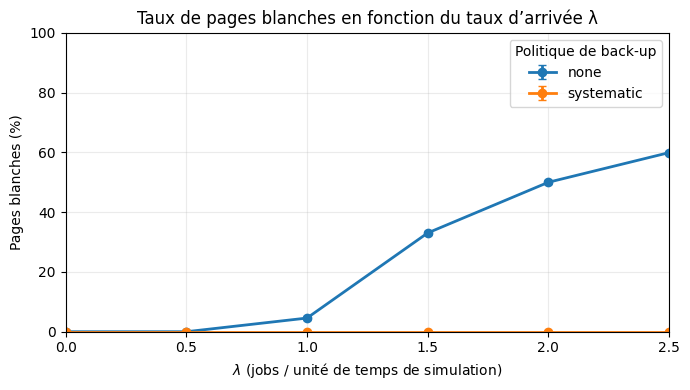

In [27]:
"""Q3.a — Analyse le CSV combiné de la cellule précédente, calcule mean±std de `rate_blocked_forward` par (λ, policy), trace une courbe avec barres d'erreur et enregistre un PNG.
Affiche aussi un tableau récapitulatif.
"""

import os
import numpy as np
import matplotlib.pyplot as plt

summary_csv = os.path.join(OUT_DIR, f"{OUT_PREFIX}_summary.csv")
df = pd.read_csv(summary_csv)

metric = "rate_blocked_forward"
g = df.groupby(["lam", "backup"])[metric]
stats = g.agg(["mean", "std", "count"]).reset_index().sort_values(["backup", "lam"])

stats["mean_pct"] = 100.0 * stats["mean"]
stats["std_pct"] = 100.0 * stats["std"].fillna(0.0)

plt.figure(figsize=(7, 4))
for backup, sub in stats.groupby("backup"):
    plt.errorbar(sub["lam"], sub["mean_pct"], yerr=sub["std_pct"], marker="o", capsize=3, linewidth=2, label=backup)

plt.title("Taux de pages blanches en fonction du taux d’arrivée λ")
plt.xlabel(r"$\lambda$ (jobs / unité de temps de simulation)")
plt.ylabel("Pages blanches (%)")
plt.grid(True, alpha=0.25)
plt.legend(title="Politique de back-up")

xvals = sorted(stats["lam"].unique().tolist())
plt.xlim(0, float(max(xvals)))
plt.xticks(xvals)
plt.ylim(0, 100)
plt.tight_layout()

plot_path = os.path.join(OUT_DIR, f"{OUT_PREFIX}_rate_blocked_forward.png")
plt.savefig(plot_path, dpi=200)
print("Wrote:", plot_path)

tab = stats.pivot(index="lam", columns="backup", values="mean_pct").reset_index()
tab = tab.rename(columns={"none": "none_mean_pct", "systematic": "systematic_mean_pct"})
if "none_mean_pct" in tab.columns and "systematic_mean_pct" in tab.columns:
    tab["gain_pct_points"] = tab["none_mean_pct"] - tab["systematic_mean_pct"]
tab = tab.round(3)
tab


**Que montrent les résultats ?**  
Sans back-up, la proportion de pages blanches augmente vite avec la charge : environ 4% à $\lambda=1.0$, environ 33% à $\lambda=1.5$, 50% à $\lambda=2.0$ et environ 60% à $\lambda=2.5$.  
Avec un back-up systématique, elle reste nulle sur toute la plage testée : les résultats bloqués ne sont plus perdus, ils sont sauvegardés puis réinjectés plus tard.


**Conclusion.**  
Le back-up transforme donc une perte visible (page blanche) en résultat différé. L’impact sur les délais et l’accumulation (backlog) est discuté dans les sous-questions suivantes.


### <span style="color:#4a90e2"> Q3.b — Problèmes/limites du back-up</span>

Le back-up permet d’éviter les pages blanches. En effet, au lieu de perdre un résultat quand la seconde file (la file de renvoi) est pleine, on le sauvegarde puis on réessaie plus tard. En revanche, cela ne résout pas la saturation : cela change simplement la forme du problème.

Quand le renvoi est le goulot d’étranglement, les résultats qui ne peuvent pas être envoyés s’accumulent dans le système, c’est-à-dire dans le back-up et/ou dans la file de renvoi. On obtient donc un backlog qui peut devenir très important. L’utilisateur ne voit plus une erreur immédiate, mais il peut attendre longtemps avant d’obtenir son résultat.

Cette accumulation a deux conséquences directes :

La latence augmente : certains résultats finissent par être renvoyés très tard.

La variabilité augmente : l’expérience devient instable ; certains obtiennent une réponse rapidement, d’autres beaucoup plus tard.

In [28]:
"""Q3.b — À forte charge (λ=2.5), exécute 30 runs pour 'none' et 'systematic' et construit les DataFrames `df_q3b` (run-level) et `df_q3b_jobs` (job-level pour les jobs complétés).
"""

import os
import pandas as pd

from waterfall_simpy import run_one

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

lam = 2.5
mu_exec = 1.0
mu_send = 1.0
K = 4
ks = None
kf = 20
sim_time = 10000
grace_time = 2000
backup_retry_dt = 0.1

runs = 30
seed0 = 42
seeds = [seed0 + run for run in range(1, runs + 1)]

backup_policies = ["none", "systematic"]

rows = []
job_rows = []
for backup in backup_policies:
    backup_key = backup_key_by_label.get(backup, backup)
    backup_label = label_by_key.get(backup_key, str(backup))
    params = {
        "lam": lam,
        "mu_exec": mu_exec,
        "mu_send": mu_send,
        "K": K,
        "ks": ks,
        "kf": kf,
        "backup": backup_key,
        "backup_p": 1.0,
        "sim_time": sim_time,
        "grace_time": grace_time,
        "backup_retry_dt": backup_retry_dt,
    }
    for run, seed in enumerate(seeds, start=1):
        s, _jobs = run_one(params, seed=seed)

        arrivals = int(s["arrivals"])
        blocked_submit = int(s["blocked_submit"])
        blocked_forward = int(s["blocked_forward"])
        completed = int(s["completed"])
        not_completed_yet = int(s["not_completed_yet"])
        rest_in_backup = int(s["rest_in_backup"])
        rest_in_forward = int(s["rest_in_forward"])

        accepted = max(0, arrivals - blocked_submit)
        denom = accepted if accepted > 0 else 1

        blank_rate_pct = 100.0 * blocked_forward / denom
        pending_rate_pct = 100.0 * not_completed_yet / denom
        delivered_rate_pct = 100.0 * completed / denom
        row = {
            "run": run,
            "seed": seed,
            "backup": backup_key,
            "policy": backup_label,
            "lam": lam,
            "arrivals": arrivals,
            "blocked_submit": blocked_submit,
            "blocked_forward": blocked_forward,
            "completed": completed,
            "not_completed_yet": not_completed_yet,
            "rest_in_backup": rest_in_backup,
            "rest_in_forward": rest_in_forward,
            "accepted": accepted,
            "blank_rate_pct": blank_rate_pct,
            "pending_rate_pct": pending_rate_pct,
            "delivered_rate_pct": delivered_rate_pct,
            "rate_blocked_forward": s["rate_blocked_forward"],
            "backlog_total": rest_in_backup + rest_in_forward,
            "rest_not_completed_yet": not_completed_yet,
            "mean_time_in_system": s["mean_time_in_system"],
            "var_time_in_system": s["var_time_in_system"],
        }
        rows.append(row)

        for j in _jobs:
            if "arrival" in j and "depart" in j:
                job_rows.append(
                    {
                        "backup": backup_key,
                        "policy": backup_label,
                        "run": run,
                        "seed": seed,
                        "time_in_system": float(j["depart"]) - float(j["arrival"]),
                        "from_backup": bool(j.get("from_backup", False)),
                    }
                )

df_q3b = pd.DataFrame(rows)
df_q3b_jobs = pd.DataFrame(job_rows)

df_q3b.head()


,run,seed,backup,lam,arrivals,blocked_submit,blocked_forward,completed,not_completed_yet,rest_in_backup,rest_in_forward,accepted,blank_rate_pct,pending_rate_pct,delivered_rate_pct,rate_blocked_forward,backlog_total,rest_not_completed_yet,mean_time_in_system,var_time_in_system
0,1,43,none,2.5,24985,0,14980,10005,0,0,0,24985,59.955974,0.0,40.044026,0.599560,0,0,21.542381,23.131867
1,2,44,none,2.5,24713,0,14832,9881,0,0,0,24713,60.016995,0.0,39.983005,0.600170,0,0,21.818642,23.771963
2,3,45,none,2.5,24971,0,14944,10027,0,0,0,24971,59.845421,0.0,40.154579,0.598454,0,0,21.500999,23.673435
3,4,46,none,2.5,25163,0,15117,10046,0,0,0,25163,60.076303,0.0,39.923697,0.600763,0,0,21.479252,23.874943
4,5,47,none,2.5,24568,0,14632,9936,0,0,0,24568,59.557148,0.0,40.442852,0.595571,0,0,21.663816,23.356314


Wrote: results/q3b_backlog_total.png
Wrote: results/q3b_result_distribution.png
Wrote: results/q3b_cdf_time_in_system.png


,metric,unit,note,none_mean,none_std,systematic_mean,systematic_std,gain_systematic_minus_none
0,backlog_total,jobs,,0.000,0.000,12989.000,224.157,12989.000
1,blank_rate_pct,%,,59.914,0.541,0.000,0.000,-59.914
2,pending_rate_pct,%,,0.000,0.000,51.996,0.613,51.996
3,delivered_rate_pct,%,,40.086,0.541,48.004,0.613,7.918
4,mean_time_in_system,unités de temps,calculé sur complétés,21.535,0.224,3466.393,50.639,3444.858
5,var_time_in_system,unités de temps²,calculé sur complétés,22.939,1.144,5540563.969,144084.457,5540541.031


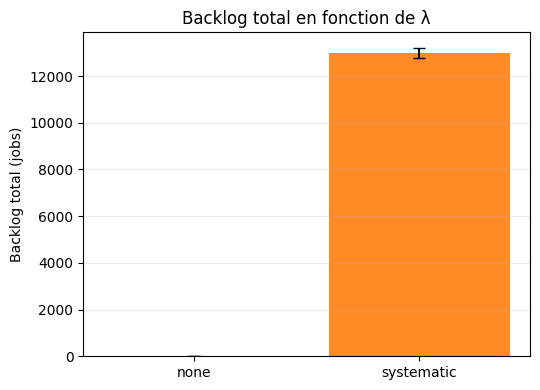

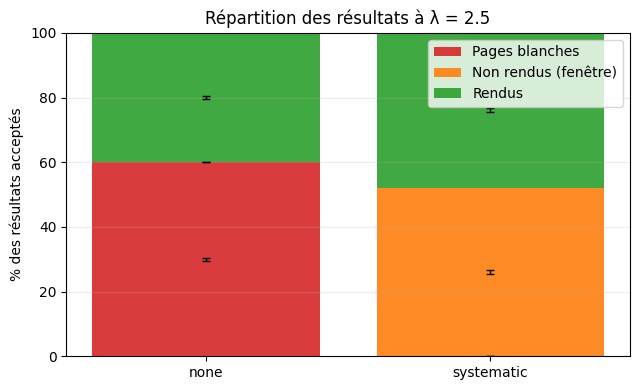

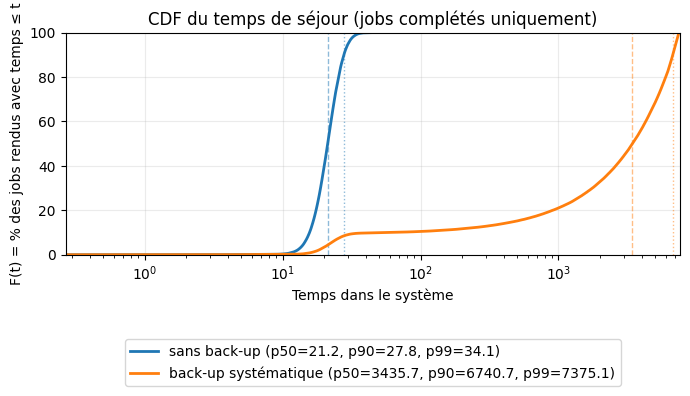

In [29]:
"""Q3.b — À partir de `df_q3b` et `df_q3b_jobs`, génère 3 graphes (backlog_total, répartition blanks/pending/delivered, CDF du temps dans le système), sauvegarde les PNG dans `results/` et affiche un tableau récapitulatif.
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

order_keys = ["none", "systematic"]
order_labels = ["sans back-up", "systématique"]
label_by_key = dict(zip(order_keys, order_labels))

def _mean_std(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    return df.groupby("backup")[metric].agg(["mean", "std"]).reindex(order_keys)

sub = _mean_std(df_q3b, "backlog_total")
means = sub["mean"].to_numpy(dtype=float)
stds = sub["std"].fillna(0.0).to_numpy(dtype=float)

x = np.arange(len(order_keys))
fig1, ax1 = plt.subplots(figsize=(5.5, 4))
ax1.bar(x, means, yerr=stds, capsize=4, color=["#1f77b4", "#ff7f0e"], alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(order_labels)
ax1.set_title("Backlog total en fonction de λ")
ax1.set_ylabel("Backlog total (jobs)")
ax1.grid(True, axis="y", alpha=0.25)
fig1.tight_layout()
path1 = os.path.join(OUT_DIR, "q3b_backlog_total.png")
fig1.savefig(path1, dpi=200)
print("Wrote:", path1)

parts = [
    ("blank_rate_pct", "Pages blanches", "#d62728"),
    ("pending_rate_pct", "Non rendus (fenêtre)", "#ff7f0e"),
    ("delivered_rate_pct", "Rendus", "#2ca02c"),
]

means_parts = {m: _mean_std(df_q3b, m)["mean"].to_numpy(dtype=float) for (m, _, _) in parts}
stds_parts = {m: _mean_std(df_q3b, m)["std"].fillna(0.0).to_numpy(dtype=float) for (m, _, _) in parts}

check = (
    pd.DataFrame({k: v for k, v in means_parts.items()}, index=order_keys)
    .assign(sum_pct=lambda d: d.sum(axis=1))
    .round(3)
)
check

fig2, ax2 = plt.subplots(figsize=(6.5, 4))
bottom = np.zeros(len(order_keys), dtype=float)
for metric, label, color in parts:
    vals = means_parts[metric]
    errs = stds_parts[metric]
    ax2.bar(x, vals, bottom=bottom, color=color, alpha=0.9, label=label)
    ax2.errorbar(x, bottom + 0.5 * vals, yerr=errs, fmt="none", ecolor="black", capsize=3, linewidth=1)
    bottom = bottom + vals

ax2.set_xticks(x)
ax2.set_xticklabels(order_labels)
ax2.set_title("Répartition des résultats à λ = 2.5")
ax2.set_ylabel("% des résultats acceptés")
ax2.set_ylim(0, 100)
ax2.grid(True, axis="y", alpha=0.25)
ax2.legend(loc="upper right")
fig2.tight_layout()
path2 = os.path.join(OUT_DIR, "q3b_result_distribution.png")
fig2.savefig(path2, dpi=200)
print("Wrote:", path2)

fig3, ax3 = plt.subplots(figsize=(7, 4))
pct_rows = []
draw_percentile_lines = True
for backup in order_keys:
    times = df_q3b_jobs.loc[df_q3b_jobs["backup"] == backup, "time_in_system"].to_numpy(dtype=float)
    times = times[np.isfinite(times)]
    if times.size == 0:
        continue
    xs = np.sort(times)
    ys = 100.0 * (np.arange(1, xs.size + 1) / xs.size)
    p50, p90, p99 = np.percentile(times, [50, 90, 99])
    pct_rows.append({"backup": backup, "p50": p50, "p90": p90, "p99": p99, "n": int(xs.size)})
    label = label_by_key.get(backup, backup)
    (line,) = ax3.plot(xs, ys, linewidth=2, label=f"{label} (p50={p50:.1f}, p90={p90:.1f}, p99={p99:.1f})")
    if draw_percentile_lines:
        c = line.get_color()
        ax3.axvline(p50, color=c, linestyle="--", alpha=0.5, linewidth=1)
        ax3.axvline(p90, color=c, linestyle=":", alpha=0.5, linewidth=1)

ax3.set_title("CDF du temps de séjour (jobs complétés uniquement)")
ax3.set_xlabel("Temps dans le système")
ax3.set_ylabel("F(t) = % des jobs rendus avec temps ≤ t")
ax3.set_xscale("log")
all_times = df_q3b_jobs["time_in_system"].to_numpy(dtype=float)
all_times = all_times[np.isfinite(all_times) & (all_times > 0)]
if all_times.size:
    ax3.set_xlim(left=float(all_times.min()), right=float(all_times.max()))
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.25)
ax3.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=1,
    frameon=True,
)
fig3.tight_layout()
fig3.subplots_adjust(bottom=0.35)
path3 = os.path.join(OUT_DIR, "q3b_cdf_time_in_system.png")
fig3.savefig(path3, dpi=200, bbox_inches="tight")
print("Wrote:", path3)

pd.DataFrame(pct_rows).round(3)

table_metrics = [
    ("backlog_total", "jobs", ""),
    ("blank_rate_pct", "%", ""),
    ("pending_rate_pct", "%", ""),
    ("delivered_rate_pct", "%", ""),
    ("mean_time_in_system", "unités de temps", "calculé sur complétés"),
    ("var_time_in_system", "unités de temps²", "calculé sur complétés"),
]

rows = []
for metric, unit, note in table_metrics:
    sub = _mean_std(df_q3b, metric)
    none_mean = float(sub.loc["none", "mean"])
    none_std = float(sub.loc["none", "std"]) if not pd.isna(sub.loc["none", "std"]) else 0.0
    sys_mean = float(sub.loc["systematic", "mean"])
    sys_std = float(sub.loc["systematic", "std"]) if not pd.isna(sub.loc["systematic", "std"]) else 0.0
    rows.append(
        {
            "metric": metric,
            "unit": unit,
            "note": note,
            "none_mean": none_mean,
            "none_std": none_std,
            "systematic_mean": sys_mean,
            "systematic_std": sys_std,
            "gain_systematic_minus_none": sys_mean - none_mean,
        }
    )

tab_q3b = pd.DataFrame(rows)
tab_q3b.round(3)


Dans nos tests à forte charge avec $\lambda=2.5$, on voit bien le compromis :

Sans back-up, il y a beaucoup de pages blanches (environ $60\%$), mais le backlog est inexistant, justement parce qu’une partie des résultats est perdue.

Avec back-up systématique, les pages blanches disparaissent, mais une grosse partie des résultats devient en attente dans la fenêtre d’observation (environ $52\%$), et le backlog explose (environ $13\,000$ résultats en attente).

Enfin, il faut faire attention à la métrique `mean_time_in_system` : elle est calculée uniquement sur les jobs rendus (complétés). Sans back-up, on mesure donc seulement les délais des jobs qui n’ont pas été perdus, ce qui peut donner une impression de latence faible si on ne regarde pas en parallèle les pages blanches et les résultats non rendus.

En conclusion, le back-up supprime une perte visible (les pages blanches), mais il peut déplacer le problème vers de l’attente et de l’accumulation, ce qui dégrade les délais et la régularité de l’expérience utilisateur.

### <span style="color:#4a90e2"> 3.c Discutez des avantages d’un back-up aléatoire plutôt que systématique.

Un back-up systématique ($p = 1$) supprime les pages blanches, mais il peut provoquer une accumulation importante si le renvoi est le goulot d’étranglement (cf. question précédente).
Un back-up aléatoire ($p \in (0,1)$) permet de régler un compromis : lorsqu’un résultat est bloqué au renvoi, on ne le sauvegarde qu’avec une probabilité $p$. Cela limite l’accumulation, mais laisse un taux non nul de pages blanches.

In [30]:
"""Q3.c — À forte charge (λ=2.5), exécute 30 runs pour différentes probabilités de back-up p (p=0→none, p=1→systematic, sinon probabilistic) et construit `df_q3c`.
"""

import os
import pandas as pd

from waterfall_simpy import run_one

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

lam = 2.5
mu_exec = 1.0
mu_send = 1.0
K = 4
ks = None
kf = 20
sim_time = 10000
grace_time = 2000
backup_retry_dt = 0.1

runs = 30
seed0 = 42
seeds = [seed0 + run for run in range(1, runs + 1)]

ps = [0.0, 0.25, 0.5, 0.75, 1.0]

rows = []
for p in ps:
    if p == 0.0:
        backup = "none"
        backup_p = 1.0
    elif p == 1.0:
        backup = "systematic"
        backup_p = 1.0
    else:
        backup = "probabilistic"
        backup_p = p

    params = {
        "lam": lam,
        "mu_exec": mu_exec,
        "mu_send": mu_send,
        "K": K,
        "ks": ks,
        "kf": kf,
        "backup": backup,
        "backup_p": backup_p,
        "sim_time": sim_time,
        "grace_time": grace_time,
        "backup_retry_dt": backup_retry_dt,
    }

    for run, seed in enumerate(seeds, start=1):
        s, _jobs = run_one(params, seed=seed)
        arrivals = int(s["arrivals"])
        blocked_submit = int(s["blocked_submit"])
        accepted = max(0, arrivals - blocked_submit)
        denom = accepted if accepted > 0 else 1

        blocked_forward = int(s["blocked_forward"])
        completed = int(s["completed"])
        not_completed_yet = int(s["not_completed_yet"])
        rest_in_backup = int(s["rest_in_backup"])
        rest_in_forward = int(s["rest_in_forward"])

        rows.append(
            {
                "p": float(p),
                "backup": backup,
                "backup_p": float(backup_p),
                "run": run,
                "seed": seed,
                "blank_rate_pct": 100.0 * blocked_forward / denom,
                "pending_rate_pct": 100.0 * not_completed_yet / denom,
                "delivered_rate_pct": 100.0 * completed / denom,
                "backlog_total": rest_in_backup + rest_in_forward,
            }
        )

df_q3c = pd.DataFrame(rows)
df_q3c.head()


,p,backup,backup_p,run,seed,blank_rate_pct,pending_rate_pct,delivered_rate_pct,backlog_total
0,0.0,none,1.0,1,43,59.955974,0.0,40.044026,0
1,0.0,none,1.0,2,44,60.016995,0.0,39.983005,0
2,0.0,none,1.0,3,45,59.845421,0.0,40.154579,0
3,0.0,none,1.0,4,46,60.076303,0.0,39.923697,0
4,0.0,none,1.0,5,47,59.557148,0.0,40.442852,0


Wrote: results/q3c_blank_rate_vs_p.png
Wrote: results/q3c_backlog_total_vs_p.png


,p,blank_rate_pct_mean,blank_rate_pct_std,pending_rate_pct_mean,pending_rate_pct_std,delivered_rate_pct_mean,delivered_rate_pct_std,backlog_total_mean,backlog_total_std
0,0.00,59.914,0.541,0.000,0.000,40.086,0.541,0.000,0.000
1,0.25,60.052,0.541,0.000,0.000,39.948,0.541,0.000,0.000
2,0.50,47.667,0.299,4.100,0.600,48.233,0.466,1023.633,154.743
3,0.75,23.835,0.308,27.980,0.557,48.185,0.503,6978.633,174.293
4,1.00,0.000,0.000,51.996,0.613,48.004,0.613,12989.000,224.157


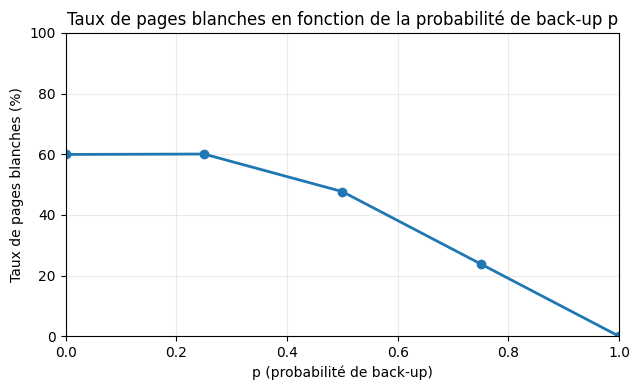

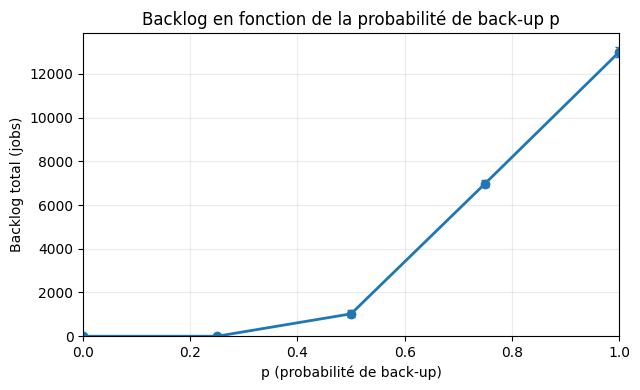

In [31]:
"""Q3.c — Agrège `df_q3c` par p, trace 2 courbes (pages blanches vs p, backlog_total vs p) avec barres d'erreur, sauvegarde les PNG dans `results/` et affiche un tableau mean/std.
"""

import numpy as np
import matplotlib.pyplot as plt

metrics = ["blank_rate_pct", "pending_rate_pct", "delivered_rate_pct", "backlog_total"]
agg = df_q3c.groupby("p")[metrics].agg(["mean", "std"]).reset_index().sort_values("p")

fig1, ax1 = plt.subplots(figsize=(6.5, 4))
ax1.errorbar(
    agg["p"],
    agg[("blank_rate_pct", "mean")],
    yerr=agg[("blank_rate_pct", "std")].fillna(0.0),
    marker="o",
    capsize=3,
    linewidth=2,
)
ax1.set_title("Taux de pages blanches en fonction de la probabilité de back-up p")
ax1.set_xlabel("p (probabilité de back-up)")
ax1.set_ylabel("Taux de pages blanches (%)")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.25)
fig1.tight_layout()
path1 = os.path.join(OUT_DIR, "q3c_blank_rate_vs_p.png")
fig1.savefig(path1, dpi=200)
print("Wrote:", path1)

fig2, ax2 = plt.subplots(figsize=(6.5, 4))
ax2.errorbar(
    agg["p"],
    agg[("backlog_total", "mean")],
    yerr=agg[("backlog_total", "std")].fillna(0.0),
    marker="o",
    capsize=3,
    linewidth=2,
)
ax2.set_title("Backlog en fonction de la probabilité de back-up p")
ax2.set_xlabel("p (probabilité de back-up)")
ax2.set_ylabel("Backlog total (jobs)")
ax2.set_xlim(0, 1)
ax2.set_ylim(bottom=0)
ax2.margins(x=0, y=0)
ax2.grid(True, alpha=0.25)
fig2.tight_layout()
path2 = os.path.join(OUT_DIR, "q3c_backlog_total_vs_p.png")
fig2.savefig(path2, dpi=200)
print("Wrote:", path2)

tab_q3c = agg.copy()
tab_q3c.columns = ["p"] + [f"{m}_{s}" for m, s in tab_q3c.columns[1:]]
tab_q3c = tab_q3c.round(3)
tab_q3c


Nos tests ($\lambda=2.5$) illustrent bien ce compromis :

Quand $p$ augmente, la proportion de pages blanches diminue ($\approx 60\%$ à $p=0$, $\approx 48\%$ à $p=0.5$, $\approx 24\%$ à $p=0.75$, et $0\%$ à $p=1$).

En parallèle, l’accumulation augmente fortement (backlog $\approx 0$ à $p=0$, $\approx 1\,000$ à $p=0.5$, $\approx 7\,000$ à $p=0.75$, $\approx 13\,000$ à $p=1$).

L’intérêt du back-up aléatoire, c’est donc qu’il permet de régler $p$ en fonction de ce qu’on cherche à optimiser :

- si on veut minimiser les pages blanches, on choisit un $p$ élevé, mais on accepte plus d’attente et de backlog ;
- si on veut limiter l’accumulation et garder des délais plus raisonnables, on choisit un $p$ plus faible, mais on accepte davantage de pertes.

En conclusion, le back-up aléatoire est avantageux car il introduit un “curseur” $p$ pour équilibrer fiabilité et surcharge, au lieu de basculer directement sur le cas extrême du back-up systématique.

### <span style="color:#4a90e2"> 3.d Calculez le temps de séjour moyen et la variance empirique dans ce modèle.

On note $T_i$ le temps de séjour d’un job $i$ : c’est le temps entre son arrivée dans le système et le moment où son résultat est effectivement renvoyé.

$$T_i = d_i - a_i$$

où $a_i$ est le temps d’arrivée et $d_i$ le temps de départ (renvoi). Ici, le temps est exprimé en unités de temps de simulation (on peut l’interpréter comme des minutes si on interprète $\lambda$ en “tags/minute”).

Sur un ensemble de $N$ jobs complétés, on estime empiriquement :

$$\bar{T} = \frac{1}{N}\sum_{i=1}^{N} T_i \qquad\text{et}\qquad \widehat{\mathrm{Var}}(T) = \frac{1}{N}\sum_{i=1}^{N}(T_i - \bar{T})^2$$

(On peut aussi utiliser la variante “échantillon” : $\frac{1}{N-1}\sum_{i=1}^{N}(T_i - \bar{T})^2$.)

In [32]:
"""Q3.d — Sur la config "stress test" (λ=2.5), exécute 30 runs pour 3 politiques (none, probabilistic p=0.5, systematic), calcule E[T] et Var(T) empiriques sur les jobs complétés, puis construit `df_q3d`.
"""

import os
import math
import pandas as pd
import statistics as st

from waterfall_simpy import run_one

OUT_DIR = "results"
os.makedirs(OUT_DIR, exist_ok=True)

params_base = {
    "lam": 2.5,
    "mu_exec": 1.0,
    "mu_send": 1.0,
    "K": 4,
    "ks": None,
    "kf": 20,
    "sim_time": 10000,
    "grace_time": 2000,
    "backup_retry_dt": 0.1,
}

runs = 30
seed0 = 42
seeds = [seed0 + r for r in range(1, runs + 1)]

policies = [
    ("none", 0.0),
    ("systematic", 1.0),
    ("probabilistic", 0.5),
]

backup_key_by_label = {
    "sans back-up": "none",
    "aléatoire": "probabilistic",
    "aleatoire": "probabilistic",
    "systématique": "systematic",
    "systematique": "systematic",
}
label_by_key = {
    "none": "sans back-up",
    "probabilistic": "aléatoire",
    "systematic": "systématique",
}

rows = []
for backup, p in policies:
    backup_key = backup_key_by_label.get(backup, backup)
    backup_label = label_by_key.get(backup_key, str(backup))

    params = dict(params_base)
    params["backup"] = backup_key
    params["backup_p"] = 1.0 if backup_key != "probabilistic" else p

    for run, seed in enumerate(seeds, start=1):
        summary, jobs = run_one(params, seed=seed)

        times = [(j["depart"] - j["arrival"]) for j in jobs]
        N = len(times)

        mean_T = (sum(times) / N) if N > 0 else math.nan

        var_T_N = st.pvariance(times) if N > 1 else math.nan

        var_T_Nm1 = st.variance(times) if N > 1 else math.nan

        rows.append({
            "backup": backup_key,
            "policy": backup_label,
            "p": p,
            "run": run,
            "seed": seed,
            "N_completed": N,
            "mean_T_emp": mean_T,
            "var_T_emp_N": var_T_N,
            "var_T_emp_Nm1": var_T_Nm1,
            "mean_time_in_system_summary": summary.get("mean_time_in_system", math.nan),
            "var_time_in_system_summary": summary.get("var_time_in_system", math.nan),
        })

df_q3d = pd.DataFrame(rows)
df_q3d.head()


,backup,p,run,seed,N_completed,mean_T_emp,var_T_emp_N,var_T_emp_Nm1,mean_time_in_system_summary,var_time_in_system_summary
0,none,0.0,1,43,10005,21.542381,23.131867,23.134180,21.542381,23.131867
1,none,0.0,2,44,9881,21.818642,23.771963,23.774369,21.818642,23.771963
2,none,0.0,3,45,10027,21.500999,23.673435,23.675796,21.500999,23.673435
3,none,0.0,4,46,10046,21.479252,23.874943,23.877320,21.479252,23.874943
4,none,0.0,5,47,9936,21.663816,23.356314,23.358665,21.663816,23.356314


Ce tableau donne, pour chaque run, le nombre de jobs complétés $N$, ainsi que `mean_T_emp` et `var_T_emp_N` calculés directement à partir des $T_i$.

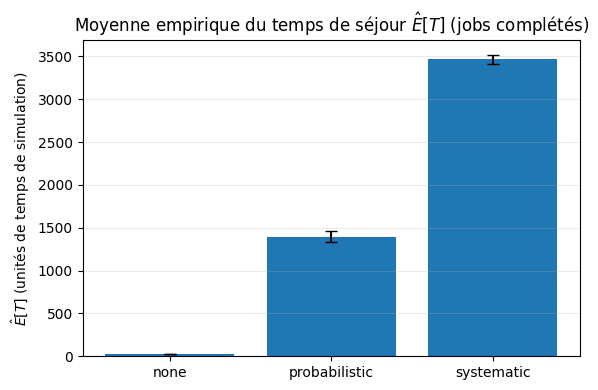

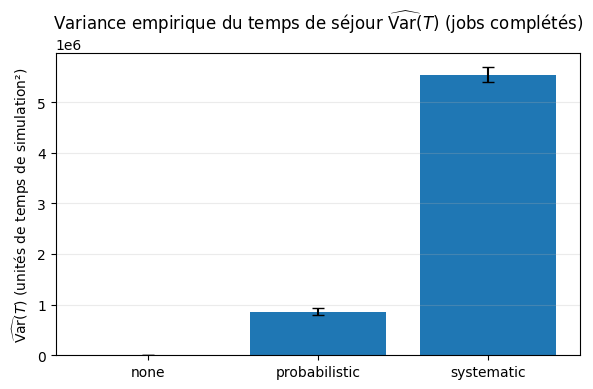

,mean_T_emp,mean_time_in_system_summary,var_T_emp_N,var_time_in_system_summary
backup,,,,
none,21.535,21.535,22.939,22.939
probabilistic,1393.677,1393.677,860521.403,860521.403
systematic,3466.393,3466.393,5540563.969,5540563.969


In [ ]:
"""Q3.d — Agrège `df_q3d` par politique, affiche un tableau mean/std, trace 2 graphes (E[T] et Var(T) en barres ± std), puis calcule un tableau de comparaison avec les métriques du résumé.
"""

import numpy as np
import matplotlib.pyplot as plt

TIME_UNIT = "unités de temps de simulation"
TIME_UNIT2 = "unités de temps de simulation²"

order_keys = ["none", "probabilistic", "systematic"]
order_labels = ["sans back-up", "aléatoire", "systématique"]
label_by_key = dict(zip(order_keys, order_labels))

agg = (
    df_q3d.groupby("backup")[["mean_T_emp", "var_T_emp_N", "N_completed"]]
    .agg(["mean", "std"])
    .reindex(order_keys)
)

tab = agg.copy()
tab.columns = [f"{a}_{b}" for (a, b) in tab.columns]
tab = tab.reset_index().rename(columns={"backup": "policy"})
tab["policy"] = tab["policy"].map(label_by_key).fillna(tab["policy"])
tab = tab.rename(
    columns={
        "mean_T_emp_mean": f"mean_T_emp_mean ({TIME_UNIT})",
        "mean_T_emp_std": f"mean_T_emp_std ({TIME_UNIT})",
        "var_T_emp_N_mean": f"var_T_emp_N_mean ({TIME_UNIT2})",
        "var_T_emp_N_std": f"var_T_emp_N_std ({TIME_UNIT2})",
    }
)
tab = tab.round(3)
tab

sub = df_q3d.groupby("backup")["mean_T_emp"].agg(["mean", "std"]).reindex(order_keys)

x = np.arange(len(order_keys))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, sub["mean"].to_numpy(), yerr=sub["std"].fillna(0).to_numpy(), capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(order_labels)
ax.set_title(r"Moyenne empirique du temps de séjour $\hat{E}[T]$ (jobs complétés)")
ax.set_ylabel(rf"$\hat{{E}}[T]$ ({TIME_UNIT})")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

sub = df_q3d.groupby("backup")["var_T_emp_N"].agg(["mean", "std"]).reindex(order_keys)

x = np.arange(len(order_keys))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x, sub["mean"].to_numpy(), yerr=sub["std"].fillna(0).to_numpy(), capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(order_labels)
ax.set_title(r"Variance empirique du temps de séjour $\widehat{\mathrm{Var}}(T)$ (jobs complétés)")
ax.set_ylabel(rf"$\widehat{{\mathrm{{Var}}}}(T)$ ({TIME_UNIT2})")
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()


check = df_q3d.groupby("backup")[[
    "mean_T_emp", "mean_time_in_system_summary",
    "var_T_emp_N", "var_time_in_system_summary"
]].mean().reindex(order_keys)

(check.rename(index=label_by_key).round(3))

Les deux graphes résument ces valeurs en moyenne ± écart-type sur 30 runs pour trois politiques : sans back-up (none), back-up probabiliste (p=0.5) et back-up systématique (systematic). On observe que la moyenne et surtout la variance augmentent fortement quand on passe à des politiques de back-up plus “fortes” (résultats moins perdus, mais rendus beaucoup plus tard à cause de l’accumulation).

Le tableau final (affiché après les graphes) sert de sanity check : mean_T_emp coïncide avec mean_time_in_system_summary et var_T_emp_N coïncide avec var_time_in_system_summary. Cela confirme que notre calcul empirique est cohérent avec les métriques internes du simulateur.

Remarque importante : ces statistiques sont calculées uniquement sur les jobs complétés (rendus). Elles doivent donc être interprétées en parallèle des taux de pages blanches et de jobs en attente vus aux questions 3.a–3.c.

Conclusion

On a donc calculé empiriquement le temps de séjour moyen et la variance à partir des temps $T_i$ des jobs complétés.
Dans notre configuration de stress test :

sans back-up (none) : $\bar{T} \approx 21.5$ et $\widehat{\mathrm{Var}}(T) \approx 22.9$ (délais faibles pour les jobs rendus, mais beaucoup de pertes ailleurs).

back-up probabiliste ($p=0.5$) : $\bar{T} \approx 1393.7$ et $\widehat{\mathrm{Var}}(T) \approx 8.6\times 10^5$.

back-up systématique (systematic) : $\bar{T} \approx 3466.4$ et $\widehat{\mathrm{Var}}(T) \approx 5.54\times 10^6$.

Autrement dit, renforcer le back-up réduit les pertes (moins de pages blanches) mais augmente fortement le temps de séjour moyen et surtout la variance, car les résultats s’accumulent et certains sont renvoyés très tard.

## <span style="color:#4a90e2"> 4) Démarche itérative</span>

On s’inscrit dans une logique d’itérations pilotées par des **métriques** :
- **Taux de pages blanches** (qualité de service côté étudiant)
- **Temps de séjour moyen** $\bar{T}$ (latence globale)
- **Variance** $\mathrm{Var}(T)$ (inégalité / imprévisibilité ressentie)
- **taux de refus** (erreurs visibles)

### Itération 1 — Baseline (charge “normale” Q1)
- Paramètres : à compléter avec la version finale Q1 (valeurs de λ, K, k_s, k_f, backup).
- Observation : pages blanches faibles / latence acceptable / variance raisonnable
- Interprétation : système stable, QoS OK.

### Itération 2 — Stress test (charge ↑ Q2)
- Changement : on augmente λ (valeur exacte à compléter avec la version finale Q2).
- Observation : explosion des pages blanches et/ou du taux de refus, $\bar{T}$ et surtout $\mathrm{Var}(T)$ augmentent
- Interprétation : saturation → expérience utilisateur très dégradée.

### Itération 3 — Mitigation (paramètres & back-up Q3)
- Changement : activer un back-up avant la file de renvoi : `none` → `systematic` ($p=1$) ou `probabilistic` ($p\in(0,1)$), éventuellement avec ajustement de $K$ et/ou $k_f$.
- Observation : `systematic` rend les pages blanches quasi nulles, mais crée un backlog / “pending” important et des temps de séjour beaucoup plus élevés (file d’attente « cachée »).
- Observation : `probabilistic` introduit un curseur $p$ : plus $p$ est grand, moins il y a de pages blanches, mais plus l’accumulation et la latence augmentent.
- Décision : choisir la politique selon la priorité (fiabilité vs latence/ressources), en fixant éventuellement une contrainte cible (ex. pages blanches ≤ $x\%$ ou backlog ≤ $y$).


## <span style="color:#4a90e2"> 5) Facteurs externes (expérience utilisateur / organisation)</span>

- **Pages blanches** : l’étudiant ne sait pas si “ça a planté” ou si “ça arrive bientôt” → il retag, spamme, et **augmente encore la charge** (boucle de rétroaction).
- **Variance élevée** : même si la moyenne est acceptable, une variance forte crée un ressenti “injuste” (certains attendent beaucoup plus), donc frustration et comportements opportunistes.
- **Erreurs explicites (refus)** : c’est frustrant, mais au moins c’est compréhensible et “actionnable” (l’étudiant sait quoi faire : attendre / retenter plus tard).
- **Back-up** : améliore la qualité perçue (moins de pages blanches) mais peut déplacer le problème (attente plus longue “invisible”) → importance d’un feedback côté front (file, ETA, statut).
